# Genel Bitki Hastaligi Tanima Modeli

**Yaklasim:** Turden bagimsiz (species-independent) 10 sinifli hastalık tespiti  
**Veri:** PlantVillage + PlantDoc + PlantPathology2021 + Cassava + Rice  
**Model:** EfficientNetB3 (transfer learning, 3 asamali fine-tuning)  
**Cikti:** TFLite modeli (mobil uygulama icin)


In [1]:
# Ne: Bellek yonetimi - MKL limitlerini ayarla
# Neden: CPU egitiminde MKL cok fazla RAM tuketiyor; bu ayarlar bellek hatasi olusmasini onler
import os
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
os.environ['TF_MKL_ALLOC_MAX_BYTES'] = '1073741824'  # 1GB MKL limiti

# Ne: GPU varligini kontrol et
# Neden: Kaggle GPU T4 x2 ile egitim cok daha hizli; local CPU ile sadece kucuk test yapilir

import tensorflow as tf
print('TensorFlow:', tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f'GPU bulundu: {len(gpus)} adet')
    for g in gpus: print(' ', g)
else:
    print('GPU yok - CPU ile calisiliyor (egitim icin Kaggle kullan)')


TensorFlow: 2.21.0
GPU yok - CPU ile calisiliyor (egitim icin Kaggle kullan)


In [2]:
# Ne: Kutuphaneleri import et
# Neden: Importlari ayri hucrede tutmak, egitim hucrelerini bagimsiz yeniden calistirmaya izin verir

import os, json, shutil, random, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
from pathlib import Path
from PIL import Image
from collections import Counter
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.applications import EfficientNetB3
print('Kutuphaneler yuklendi.')


Kutuphaneler yuklendi.


In [4]:
# Ne: Calisma ortamini belirle, tum path ve hiperparametreleri tanimla
# Neden: ENV degiskeni local/Kaggle gecisini otomatik yapar; tum ayarlar tek hucrede olunca kolayca degistirilebilir

ENV = os.environ.get('PLANT_ENV', 'local')  # 'local' veya 'kaggle'

if ENV == 'kaggle':
    RAW = '/kaggle/input'
    OUT = '/kaggle/working'
else:
    RAW = 'C:/Users/HP/Desktop/plant_project_hastalık/plant_project/data/raw'
    OUT = 'C:/Users/HP/Desktop/plant_project_hastalık/plant_project'

PV_TRAIN_DIR = f'{RAW}/plantvillage/dataset/New Plant Diseases Dataset(Augmented)/train'
PDOC_DIR     = f'{RAW}/plantdoc'
PP21_DIR     = f'{RAW}/plant_pathology_2021'
CASSAVA_DIR  = f'{RAW}/cassava'
RICE_DIR     = f'{RAW}/rice'

COMBINED_DIR = f'{OUT}/data/combined_disease_dataset'
MODEL_PATH   = f'{OUT}/models/best_disease_model.keras'
TFLITE_PATH  = f'{OUT}/models/plant_disease_model.tflite'
LABEL_PATH   = f'{OUT}/models/disease_class_names.json'

IMG_SIZE    = 224
BATCH_SIZE  = 16
EPOCHS_HEAD = 10
EPOCHS_FIN1 = 15
EPOCHS_FIN2 = 10
SEED        = 42

DISEASE_CLASSES = sorted(['bacterial','blight','healthy','leaf_spot',
                           'mold','pest_damage','powdery_mildew','rot','rust','viral'])
NUM_CLASSES = len(DISEASE_CLASSES)

random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
print(f'ENV: {ENV}')
print(f'Sinif sayisi: {NUM_CLASSES} -> {DISEASE_CLASSES}')
print(f'Combined dir: {COMBINED_DIR}')


ENV: local
Sinif sayisi: 10 -> ['bacterial', 'blight', 'healthy', 'leaf_spot', 'mold', 'pest_damage', 'powdery_mildew', 'rot', 'rust', 'viral']
Combined dir: C:/Users/HP/Desktop/plant_project_hastalık/plant_project/data/combined_disease_dataset


In [5]:
# Ne: Her dataset icin orijinal etiket -> genel hastalik kategorisi eslestirmesi
# Neden: 5 farkli datasetteki 80+ etiket, 10 genel gorsel kategoriye indirgeniyor;
#        boylece model tur bagimsiz hastalik deseni ogreniyor

PV_MAP = {
    'Apple___Apple_scab':                         'leaf_spot',
    'Apple___Black_rot':                           'rot',
    'Apple___Cedar_apple_rust':                    'rust',
    'Apple___healthy':                             'healthy',
    'Blueberry___healthy':                         'healthy',
    'Cherry_(including_sour)___Powdery_mildew':    'powdery_mildew',
    'Cherry_(including_sour)___healthy':           'healthy',
    'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot': 'leaf_spot',
    'Corn_(maize)___Common_rust_':                 'rust',
    'Corn_(maize)___Northern_Leaf_Blight':         'blight',
    'Corn_(maize)___healthy':                      'healthy',
    'Grape___Black_rot':                           'rot',
    'Grape___Esca_(Black_Measles)':                'leaf_spot',
    'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)':  'blight',
    'Grape___healthy':                             'healthy',
    'Orange___Haunglongbing_(Citrus_greening)':    'viral',
    'Peach___Bacterial_spot':                      'bacterial',
    'Peach___healthy':                             'healthy',
    'Pepper,_bell___Bacterial_spot':               'bacterial',
    'Pepper,_bell___healthy':                      'healthy',
    'Potato___Early_blight':                       'blight',
    'Potato___Late_blight':                        'blight',
    'Potato___healthy':                            'healthy',
    'Raspberry___healthy':                         'healthy',
    'Soybean___healthy':                           'healthy',
    'Squash___Powdery_mildew':                     'powdery_mildew',
    'Strawberry___Leaf_scorch':                    'leaf_spot',
    'Strawberry___healthy':                        'healthy',
    'Tomato___Bacterial_spot':                     'bacterial',
    'Tomato___Early_blight':                       'blight',
    'Tomato___Late_blight':                        'blight',
    'Tomato___Leaf_Mold':                          'mold',
    'Tomato___Septoria_leaf_spot':                 'leaf_spot',
    'Tomato___Spider_mites Two-spotted_spider_mite': 'pest_damage',
    'Tomato___Target_Spot':                        'leaf_spot',
    'Tomato___Tomato_Yellow_Leaf_Curl_Virus':      'viral',
    'Tomato___Tomato_mosaic_virus':                'viral',
    'Tomato___healthy':                            'healthy',
}

PDOC_MAP = {
    'Apple Scab Leaf':            'leaf_spot',
    'Apple leaf':                 'healthy',
    'Apple rust leaf':            'rust',
    'Bell_pepper leaf':           'healthy',
    'Bell_pepper leaf spot':      'leaf_spot',
    'Blueberry leaf':             'healthy',
    'Cherry leaf':                'healthy',
    'Corn Gray leaf spot':        'leaf_spot',
    'Corn leaf blight':           'blight',
    'Corn rust leaf':             'rust',
    'Peach leaf':                 'healthy',
    'Potato leaf':                'healthy',
    'Potato leaf early blight':   'blight',
    'Potato leaf late blight':    'blight',
    'Raspberry leaf':             'healthy',
    'Soyabean leaf':              'healthy',
    'Soybean leaf':               'healthy',
    'Squash Powdery mildew leaf': 'powdery_mildew',
    'Strawberry leaf':            'healthy',
    'Tomato Early blight leaf':   'blight',
    'Tomato Septoria leaf spot':  'leaf_spot',
    'Tomato leaf':                'healthy',
    'Tomato leaf bacterial spot': 'bacterial',
    'Tomato leaf late blight':    'blight',
    'Tomato leaf mosaic virus':   'viral',
    'Tomato leaf yellow virus':   'viral',
    'Tomato mold leaf':           'mold',
    'Tomato two spotted spider mites leaf': 'pest_damage',
    'grape leaf':                 'healthy',
    'grape leaf black rot':       'rot',
}

PP21_MAP = {
    'scab':               'leaf_spot',
    'healthy':            'healthy',
    'frog_eye_leaf_spot': 'leaf_spot',
    'rust':               'rust',
    'powdery_mildew':     'powdery_mildew',
    'complex':            None,
}

CASSAVA_MAP = {
    0: 'bacterial',
    1: 'blight',
    2: 'leaf_spot',
    3: 'viral',
    4: 'healthy',
}

RICE_MAP = {
    'Bacterial leaf blight': 'bacterial',
    'Brown spot':            'leaf_spot',
    'Leaf smut':             'mold',
    'Healthy':               'healthy',
    'healthy':               'healthy',
    'hispa':                 'pest_damage',
    'blast':                 'blight',
    'tungro':                'viral',
}

print('Label eslestirmeleri hazir.')


Label eslestirmeleri hazir.


In [5]:
# Ne: Veri toplama ve kopyalama yardimci fonksiyonlari
# Neden: Ayni mantigi her dataset icin tekrar yazmamak; moduler tutmak

VALID_EXT = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff'}

def is_valid_image(path):
    try:
        with Image.open(path) as img: img.verify()
        return True
    except Exception:
        return False

def copy_image(src, dst_dir, label, counter):
    dst = os.path.join(dst_dir, label)
    os.makedirs(dst, exist_ok=True)
    ext = Path(src).suffix.lower()
    fname = f'{label}_{counter:06d}{ext}'
    shutil.copy2(src, os.path.join(dst, fname))

def collect_from_folders(root, label_map, dst_dir, counters):
    added = 0
    for folder in os.listdir(root):
        label = label_map.get(folder)
        if label is None:
            continue
        folder_path = os.path.join(root, folder)
        if not os.path.isdir(folder_path):
            continue
        for fname in os.listdir(folder_path):
            if Path(fname).suffix.lower() not in VALID_EXT:
                continue
            counters[label] = counters.get(label, 0) + 1
            copy_image(os.path.join(folder_path, fname), dst_dir, label, counters[label])
            added += 1
    return added

print('Yardimci fonksiyonlar tanimlandi.')


Yardimci fonksiyonlar tanimlandi.


In [6]:
# Ne: PlantVillage verisetini topla ve genel etiketlere donustur
# Neden: PlantVillage en buyuk ve temiz dataset; 38 sinif -> 10 genel sinife donusturuluyor

print('PlantVillage toplanıyor...')
pv_counters = {}
if os.path.exists(PV_TRAIN_DIR):
    pv_added = collect_from_folders(PV_TRAIN_DIR, PV_MAP, COMBINED_DIR, pv_counters)
    print(f'  Eklendi: {pv_added} resim')
    for lbl, cnt in sorted(pv_counters.items()): print(f'    {lbl}: {cnt}')
else:
    print(f'  [UYARI] Dizin bulunamadi: {PV_TRAIN_DIR}')


PlantVillage toplanıyor...
  Eklendi: 70295 resim
    bacterial: 5453
    blight: 11279
    healthy: 22294
    leaf_spot: 10924
    mold: 1882
    pest_damage: 1741
    powdery_mildew: 3419
    rot: 3875
    rust: 3667
    viral: 5761


In [7]:
# Ne: PlantDoc verisetini topla
# Neden: Gercek saha fotograflari iceriyor; lab ortami (PlantVillage) ile dengeliyor

print('PlantDoc toplanıyor...')
pdoc_counters = {}
pdoc_added = 0
if os.path.exists(PDOC_DIR):
    for split in ['train', 'test', '']:
        sp = os.path.join(PDOC_DIR, split) if split else PDOC_DIR
        if os.path.exists(sp):
            a = collect_from_folders(sp, PDOC_MAP, COMBINED_DIR, pdoc_counters)
            pdoc_added += a
            if a > 0 and not split: break
    print(f'  Eklendi: {pdoc_added} resim')
    for lbl, cnt in sorted(pdoc_counters.items()): print(f'    {lbl}: {cnt}')
else:
    print(f'  [UYARI] Dizin bulunamadi: {PDOC_DIR}')


PlantDoc toplanıyor...
  Eklendi: 2477 resim
    bacterial: 105
    blight: 598
    healthy: 811
    leaf_spot: 364
    mold: 85
    pest_damage: 2
    powdery_mildew: 126
    rot: 60
    rust: 198
    viral: 128


In [8]:
# Ne: Plant Pathology 2021 verisetini CSV'den topla
# Neden: Gercek elma fotograflari iceriyor; CSV tabanli etiket okuma ornegi

print('Plant Pathology 2021 toplanıyor...')
pp21_counters = {}
pp21_added = 0
if os.path.exists(PP21_DIR):
    # Direkt train.csv ara; yoksa adi 'train' iceren csv'yi bul
    csv_path = os.path.join(PP21_DIR, 'train.csv')
    if not os.path.exists(csv_path):
        for fn in sorted(os.listdir(PP21_DIR)):
            if fn.endswith('.csv') and 'train' in fn.lower():
                csv_path = os.path.join(PP21_DIR, fn); break
    img_dir = os.path.join(PP21_DIR, 'train_images')
    if not os.path.exists(img_dir): img_dir = PP21_DIR
    if os.path.exists(csv_path):
        df = pd.read_csv(csv_path)
        print(f'  CSV: {os.path.basename(csv_path)}, Sutunlar: {list(df.columns)}')
        label_col = 'labels' if 'labels' in df.columns else df.columns[-1]
        img_col   = 'image'  if 'image'  in df.columns else df.columns[0]
        for _, row in df.iterrows():
            raw = str(row[label_col]).strip().split()[0]
            gen = PP21_MAP.get(raw)
            if gen is None: continue
            img_name = str(row[img_col])
            if not img_name.endswith('.jpg'): img_name += '.jpg'
            src = os.path.join(img_dir, img_name)
            if not os.path.exists(src): continue
            pp21_counters[gen] = pp21_counters.get(gen, 0) + 1
            copy_image(src, COMBINED_DIR, gen, pp21_counters[gen])
            pp21_added += 1
        print(f'  Eklendi: {pp21_added} resim')
        for lbl, cnt in sorted(pp21_counters.items()): print(f'    {lbl}: {cnt}')
    else:
        print('  [UYARI] train.csv bulunamadi')
else:
    print(f'  [UYARI] Dizin bulunamadi: {PP21_DIR}')


Plant Pathology 2021 toplanıyor...
  CSV: train.csv, Sutunlar: ['image', 'labels']
  Eklendi: 17030 resim
    healthy: 4624
    leaf_spot: 9058
    powdery_mildew: 1271
    rust: 2077


In [9]:
# Ne: Cassava Leaf Disease verisetini CSV'den topla
# Neden: Tropikal bitki hastalikları ekleyerek cografik cesitliligi artiriyor

print('Cassava toplanıyor...')
cassava_counters = {}
cassava_added = 0
if os.path.exists(CASSAVA_DIR):
    csv_path = os.path.join(CASSAVA_DIR, 'train.csv')
    img_dir  = os.path.join(CASSAVA_DIR, 'train_images')
    if os.path.exists(csv_path) and os.path.exists(img_dir):
        df = pd.read_csv(csv_path)
        print(f'  Sutunlar: {list(df.columns)}')
        img_col   = 'image_id' if 'image_id' in df.columns else df.columns[0]
        label_col = 'label'    if 'label'    in df.columns else df.columns[1]
        for _, row in df.iterrows():
            gen = CASSAVA_MAP.get(int(row[label_col]))
            if gen is None: continue
            src = os.path.join(img_dir, str(row[img_col]))
            if not os.path.exists(src): continue
            cassava_counters[gen] = cassava_counters.get(gen, 0) + 1
            copy_image(src, COMBINED_DIR, gen, cassava_counters[gen])
            cassava_added += 1
        print(f'  Eklendi: {cassava_added} resim')
        for lbl, cnt in sorted(cassava_counters.items()): print(f'    {lbl}: {cnt}')
    else:
        print('  [UYARI] CSV veya resim dizini bulunamadi')
else:
    print(f'  [UYARI] Dizin bulunamadi: {CASSAVA_DIR}')


Cassava toplanıyor...
  Sutunlar: ['image_id', 'label']
  Eklendi: 21397 resim
    bacterial: 1087
    blight: 2189
    healthy: 2577
    leaf_spot: 2386
    viral: 13158


In [10]:
# Ne: Rice Leaf Disease verisetini topla
# Neden: Tahil bitkisi ekleyerek model cesitliligini artiriyor; pest_damage ve blight icin ek ornek sagliyor

print('Rice toplanıyor...')
rice_counters = {}
rice_added = 0
if os.path.exists(RICE_DIR):
    # Dizin yapısını otomatik tara: rice/, rice/train/, rice/data/, rice/rice_leaf_diseases/ gibi
    search_paths = [RICE_DIR]
    for sub in os.listdir(RICE_DIR):
        sp = os.path.join(RICE_DIR, sub)
        if os.path.isdir(sp):
            search_paths.append(sp)
    for sp in search_paths:
        a = collect_from_folders(sp, RICE_MAP, COMBINED_DIR, rice_counters)
        rice_added += a
        if a > 0: break
    print(f'  Eklendi: {rice_added} resim')
    for lbl, cnt in sorted(rice_counters.items()): print(f'    {lbl}: {cnt}')
else:
    print(f'  [UYARI] Dizin bulunamadi: {RICE_DIR}')


Rice toplanıyor...
  Eklendi: 120 resim
    bacterial: 40
    leaf_spot: 40
    mold: 40


Birlestirilmis veri seti istatistikleri:
  bacterial           :   5453
  blight              :  11280
  healthy             :  22294
  leaf_spot           :  10925
  mold                :   1882
  pest_damage         :   1741
  powdery_mildew      :   3419
  rot                 :   3875
  rust                :   3667
  viral               :  13158
  TOPLAM: 77694 resim, 10 sinif


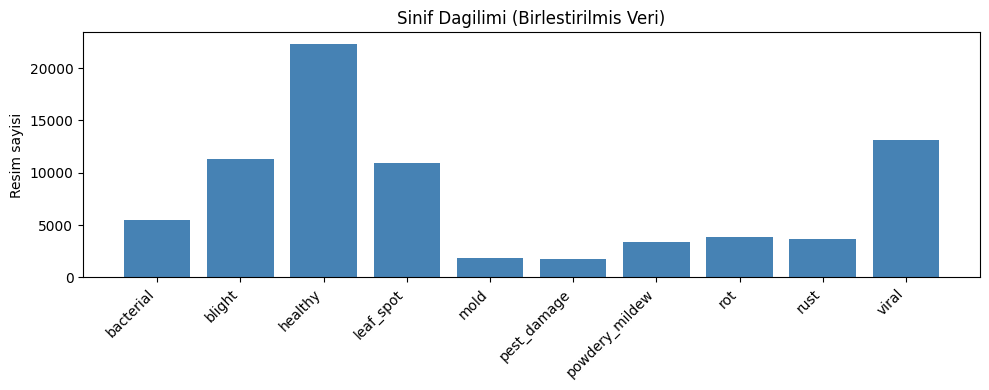

In [11]:
# Ne: Birlestirilmis veri setinin istatistiklerini goster
# Neden: Sinif dengesizligini gormek; class weight hesabi icin ongorun saglamak

print('Birlestirilmis veri seti istatistikleri:')
print('=' * 45)
total = 0
class_counts = {}
if os.path.exists(COMBINED_DIR):
    for cls in sorted(os.listdir(COMBINED_DIR)):
        cp = os.path.join(COMBINED_DIR, cls)
        if os.path.isdir(cp):
            n = len([f for f in os.listdir(cp) if Path(f).suffix.lower() in VALID_EXT])
            class_counts[cls] = n; total += n
    for cls, n in sorted(class_counts.items()):
        print(f'  {cls:20s}: {n:6d}')
    print(f'  TOPLAM: {total} resim, {len(class_counts)} sinif')
else:
    print('  [UYARI] COMBINED_DIR bulunamadi!')

if class_counts:
    plt.figure(figsize=(10, 4))
    plt.bar(class_counts.keys(), class_counts.values(), color='steelblue')
    plt.xticks(rotation=45, ha='right'); plt.ylabel('Resim sayisi')
    plt.title('Sinif Dagilimi (Birlestirilmis Veri)'); plt.tight_layout(); plt.show()


In [12]:
# Ne: Veriyi train/val/test olarak bol ve dosyalari kopyala
# Neden: Kesin ayirma yapilmadan model degerlendirilmesi yaniltici olur

SPLIT_DIR   = os.path.join(OUT, 'data', 'split_disease_dataset')
TRAIN_RATIO = 0.75
VAL_RATIO   = 0.15

def split_dataset(combined_dir, split_dir, train_r=0.75, val_r=0.15, seed=42):
    random.seed(seed)
    for cls in sorted(os.listdir(combined_dir)):
        cls_src = os.path.join(combined_dir, cls)
        if not os.path.isdir(cls_src): continue
        files = [f for f in os.listdir(cls_src) if Path(f).suffix.lower() in VALID_EXT]
        random.shuffle(files)
        n = len(files)
        n_train = int(n * train_r); n_val = int(n * val_r)
        for split_name, flist in [('train', files[:n_train]),
                                   ('val',   files[n_train:n_train+n_val]),
                                   ('test',  files[n_train+n_val:])]:
            dst = os.path.join(split_dir, split_name, cls)
            os.makedirs(dst, exist_ok=True)
            for f in flist: shutil.copy2(os.path.join(cls_src, f), os.path.join(dst, f))
        print(f'  {cls:20s}: train={n_train}, val={n_val}, test={n-n_train-n_val}')

if not os.path.exists(SPLIT_DIR) or not os.listdir(SPLIT_DIR):
    print('Veri bolunuyor...')
    split_dataset(COMBINED_DIR, SPLIT_DIR, TRAIN_RATIO, VAL_RATIO, SEED)
    print('Bolme tamamlandi.')
else:
    print('Split zaten mevcut, atlaniyor.')

TRAIN_DIR = os.path.join(SPLIT_DIR, 'train')
VAL_DIR   = os.path.join(SPLIT_DIR, 'val')
TEST_DIR  = os.path.join(SPLIT_DIR, 'test')


Split zaten mevcut, atlaniyor.


In [6]:
# Ne: Bolme sonucunu dogrula
# Neden: Bos sinif veya eksik klasor varsa egitim hata verir; erkenden yakala

print('Split dogrulamasi:')
for split in ['train', 'val', 'test']:
    sp = os.path.join(SPLIT_DIR, split)
    tot = sum(len(os.listdir(os.path.join(sp, c)))
              for c in os.listdir(sp) if os.path.isdir(os.path.join(sp, c)))
    print(f'  {split:5s}: {tot} resim')


Split dogrulamasi:


NameError: name 'SPLIT_DIR' is not defined

In [14]:
# Ne: Veri artirma katmani ve tf.data pipeline olustur
# Neden: Augmentation overfitting'i azaltir; cache+prefetch GPU'yu bosaltmadan veri saglar

augmentation_layer = tf.keras.Sequential([
    layers.RandomFlip('horizontal_and_vertical'),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.15),
    layers.RandomBrightness(0.15),
    layers.RandomContrast(0.15),
    layers.RandomTranslation(0.1, 0.1),
], name='augmentation')

def load_and_preprocess(image_path, label):
    img = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32)  # EfficientNetB3 kendi icinde preprocess yapar, [0,255] bekler
    return img, label

def make_dataset(directory, training=False):
    classes = sorted(os.listdir(directory))
    class_to_idx = {c: i for i, c in enumerate(classes)}
    paths, labels = [], []
    for cls in classes:
        cp = os.path.join(directory, cls)
        for f in os.listdir(cp):
            if Path(f).suffix.lower() in VALID_EXT:
                paths.append(os.path.join(cp, f))
                labels.append(class_to_idx[cls])
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if training: ds = ds.shuffle(len(paths), seed=SEED)
    ds = ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    if training:
        ds = ds.map(lambda x, y: (augmentation_layer(x, training=True), y),
                    num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).cache().prefetch(tf.data.AUTOTUNE)
    return ds, classes

print('Dataset pipeline hazir. Yukleniyor...')
train_ds, class_names = make_dataset(TRAIN_DIR, training=True)
val_ds,   _           = make_dataset(VAL_DIR,   training=False)
test_ds,  _           = make_dataset(TEST_DIR,  training=False)
print(f'Siniflar ({len(class_names)}): {class_names}')
print(f'Train batch sayisi: {len(train_ds)}')


Dataset pipeline hazir. Yukleniyor...
Siniflar (10): ['bacterial', 'blight', 'healthy', 'leaf_spot', 'mold', 'pest_damage', 'powdery_mildew', 'rot', 'rust', 'viral']
Train batch sayisi: 3642


In [15]:
# Ne: Sinif agirliklarini hesapla
# Neden: Veri dengesizliginde (ornegin healthy >> pest_damage) model buyuk sinifi ezberleyebilir

train_labels = []
for cls_idx, cls in enumerate(class_names):
    cp = os.path.join(TRAIN_DIR, cls)
    n  = len([f for f in os.listdir(cp) if Path(f).suffix.lower() in VALID_EXT])
    train_labels.extend([cls_idx] * n)

cw_arr = compute_class_weight('balanced', classes=np.arange(NUM_CLASSES), y=train_labels)
class_weight_dict = {i: w for i, w in enumerate(cw_arr)}
print('Sinif agirliklari:')
for cls, w in zip(class_names, cw_arr):
    print(f'  {cls:20s}: {w:.3f}')


Sinif agirliklari:
  bacterial           : 1.425
  blight              : 0.689
  healthy             : 0.348
  leaf_spot           : 0.711
  mold                : 4.129
  pest_damage         : 4.465
  powdery_mildew      : 2.272
  rot                 : 2.005
  rust                : 2.119
  viral               : 0.590


In [16]:
# Ne: EfficientNetB3 tabanli modeli olustur
# Neden: EfficientNetB3 parametre/dogruluk dengesi iyi; ImageNet agirliklari hastalik tespitini hizlandirir

def build_model(num_classes):
    base = EfficientNetB3(include_top=False, weights='imagenet',
                          input_shape=(IMG_SIZE, IMG_SIZE, 3))
    base.trainable = False
    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    return models.Model(inputs, outputs), base

model, base_model = build_model(NUM_CLASSES)
model.summary()
print(f'Base model katman sayisi: {len(base_model.layers)}')


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb3 (Functional)     │ (None, 7, 7, 1536)     │    10,783,535 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1536)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1536)           │         6,144 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       786,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,710,521 (44.67 MB)

 Trainable params: 923,914 (3.52 MB)

 Non-trainable params: 10,786,607 (41.15 MB)

Base model katman sayisi: 385


In [17]:
# Ne: Egitim callback'lerini tanimla
# Neden: EarlyStopping asiri egitimi onler; ModelCheckpoint en iyi agirligi kaydeder;
#        ReduceLROnPlateau platoda LR otomatik duser

os.makedirs(os.path.dirname(MODEL_PATH), exist_ok=True)

def get_callbacks(phase):
    return [
        callbacks.ModelCheckpoint(MODEL_PATH, monitor='val_accuracy',
                                  save_best_only=True, verbose=1),
        callbacks.EarlyStopping(monitor='val_accuracy', patience=5,
                                restore_best_weights=True, verbose=1),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.3,
                                    patience=3, min_lr=1e-7, verbose=1),
        callbacks.CSVLogger(f'{OUT}/models/training_{phase}.csv'),
    ]

print("Callback'ler hazir.")


Callback'ler hazir.


In [18]:
# Ne: 1. Asama - Sadece head katmanlarini egit (base frozen)
# Neden: Base model frozen tutulursa ImageNet ozellikleri bozulmaz;
#        head once hastalık siniflarini ogrensin, sonra fine-tune yapilsin

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)
print('=== ASAMA 1: Head Egitimi ===')
history_head = model.fit(
    train_ds, validation_data=val_ds, epochs=EPOCHS_HEAD,
    class_weight=class_weight_dict, callbacks=get_callbacks('phase1'), verbose=1
)


=== ASAMA 1: Head Egitimi ===
Epoch 1/10
3642/3642 ━━━━━━━━━━━━━━━━━━━━ 0s 753ms/step - accuracy: 0.6035 - loss: 1.1444
Epoch 1: val_accuracy improved from None to 0.78567, saving model to C:/Users/HP/Desktop/plant_project_hastalık/plant_project/models/best_disease_model.keras

Epoch 1: finished saving model to C:/Users/HP/Desktop/plant_project_hastalık/plant_project/models/best_disease_model.keras
3642/3642 ━━━━━━━━━━━━━━━━━━━━ 3147s 862ms/step - accuracy: 0.6705 - loss: 0.8976 - val_accuracy: 0.7857 - val_loss: 0.5832 - learning_rate: 0.0010
Epoch 2/10
3642/3642 ━━━━━━━━━━━━━━━━━━━━ 0s 538ms/step - accuracy: 0.7319 - loss: 0.6989
Epoch 2: val_accuracy did not improve from 0.78567
3642/3642 ━━━━━━━━━━━━━━━━━━━━ 2338s 642ms/step - accuracy: 0.7397 - loss: 0.6675 - val_accuracy: 0.7845 - val_loss: 0.6101 - learning_rate: 0.0010
Epoch 3/10
3642/3642 ━━━━━━━━━━━━━━━━━━━━ 0s 536ms/step - accuracy: 0.7583 - loss: 0.6168
Epoch 3: val_accuracy improved from 0.78567 to 0.81021, saving model to

In [19]:
# Ne: 2. Asama - Son 50 katmani unfreeze edip dusuk LR ile egit
# Neden: Derin katmanlar hastalik dokusunu ogrensin; yuksek LR pretrained agirliklari bozar

base_model.trainable = True
freeze_until = len(base_model.layers) - 50
for layer in base_model.layers[:freeze_until]: layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)
print('=== ASAMA 2: Son 50 Katman Fine-tune ===')
history_fine1 = model.fit(
    train_ds, validation_data=val_ds, epochs=EPOCHS_FIN1,
    class_weight=class_weight_dict, callbacks=get_callbacks('phase2'), verbose=1
)


=== ASAMA 2: Son 50 Katman Fine-tune ===
Epoch 1/15
3642/3642 ━━━━━━━━━━━━━━━━━━━━ 0s 701ms/step - accuracy: 0.7661 - loss: 0.6221
Epoch 1: val_accuracy improved from None to 0.85845, saving model to C:/Users/HP/Desktop/plant_project_hastalık/plant_project/models/best_disease_model.keras

Epoch 1: finished saving model to C:/Users/HP/Desktop/plant_project_hastalık/plant_project/models/best_disease_model.keras
3642/3642 ━━━━━━━━━━━━━━━━━━━━ 2957s 808ms/step - accuracy: 0.7970 - loss: 0.5074 - val_accuracy: 0.8585 - val_loss: 0.3909 - learning_rate: 1.0000e-04
Epoch 2/15
3642/3642 ━━━━━━━━━━━━━━━━━━━━ 0s 697ms/step - accuracy: 0.8384 - loss: 0.3620
Epoch 2: val_accuracy improved from 0.85845 to 0.87502, saving model to C:/Users/HP/Desktop/plant_project_hastalık/plant_project/models/best_disease_model.keras

Epoch 2: finished saving model to C:/Users/HP/Desktop/plant_project_hastalık/plant_project/models/best_disease_model.keras
3642/3642 ━━━━━━━━━━━━━━━━━━━━ 2921s 802ms/step - accuracy: 

In [20]:
# Ne: 3. Asama - Son 100 katmani unfreeze edip cok dusuk LR ile egit
# Neden: Daha derin ozelliklerin ince ayari; LR cok buyuk olursa catastrophic forgetting yasanir

freeze2 = len(base_model.layers) - 100
for layer in base_model.layers[:freeze2]:  layer.trainable = False
for layer in base_model.layers[freeze2:]:  layer.trainable = True

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-5),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)
print('=== ASAMA 3: Son 100 Katman Fine-tune ===')
history_fine2 = model.fit(
    train_ds, validation_data=val_ds, epochs=EPOCHS_FIN2,
    class_weight=class_weight_dict, callbacks=get_callbacks('phase3'), verbose=1
)


=== ASAMA 3: Son 100 Katman Fine-tune ===
Epoch 1/10
3642/3642 ━━━━━━━━━━━━━━━━━━━━ 0s 826ms/step - accuracy: 0.9364 - loss: 0.1183
Epoch 1: val_accuracy improved from None to 0.90352, saving model to C:/Users/HP/Desktop/plant_project_hastalık/plant_project/models/best_disease_model.keras

Epoch 1: finished saving model to C:/Users/HP/Desktop/plant_project_hastalık/plant_project/models/best_disease_model.keras
3642/3642 ━━━━━━━━━━━━━━━━━━━━ 3429s 938ms/step - accuracy: 0.9371 - loss: 0.1149 - val_accuracy: 0.9035 - val_loss: 0.3554 - learning_rate: 5.0000e-05
Epoch 2/10
3642/3642 ━━━━━━━━━━━━━━━━━━━━ 0s 822ms/step - accuracy: 0.9446 - loss: 0.0963
Epoch 2: val_accuracy improved from 0.90352 to 0.91399, saving model to C:/Users/HP/Desktop/plant_project_hastalık/plant_project/models/best_disease_model.keras

Epoch 2: finished saving model to C:/Users/HP/Desktop/plant_project_hastalık/plant_project/models/best_disease_model.keras
3642/3642 ━━━━━━━━━━━━━━━━━━━━ 3401s 934ms/step - accuracy:

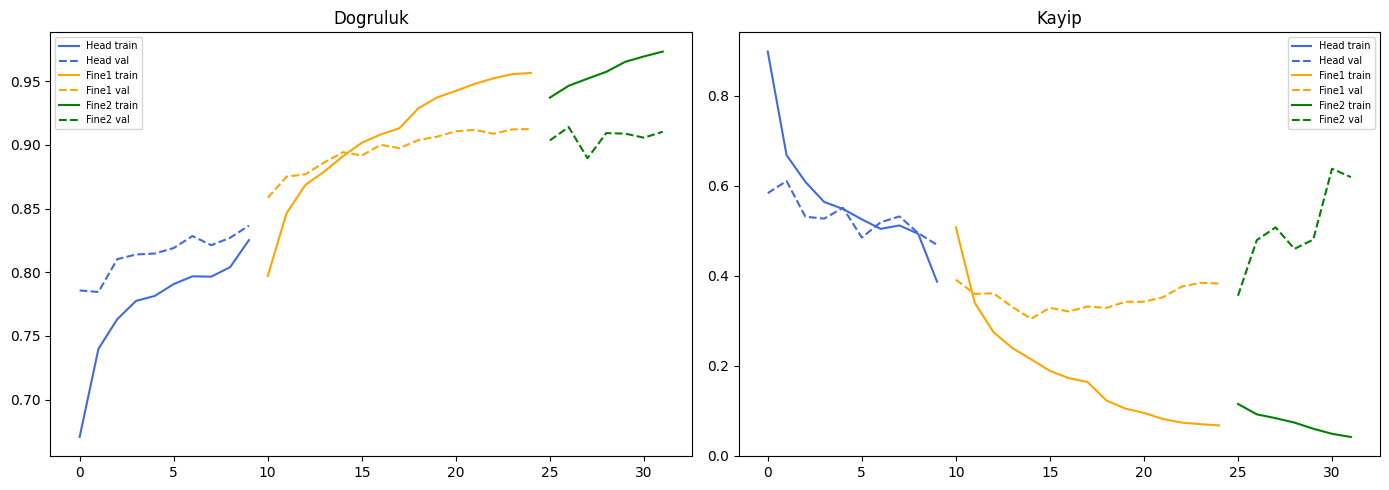

In [21]:
# Ne: Egitim egrileri grafigi
# Neden: Overfitting, underfitting veya learning rate sorunlarini gorsel olarak tespit etmek

def plot_history(histories, labels):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    colors = ['royalblue', 'orange', 'green']
    offset = 0
    for hist, lbl, col in zip(histories, labels, colors):
        ep = range(offset, offset + len(hist.history['accuracy']))
        axes[0].plot(ep, hist.history['accuracy'],     color=col, label=f'{lbl} train')
        axes[0].plot(ep, hist.history['val_accuracy'], color=col, ls='--', label=f'{lbl} val')
        axes[1].plot(ep, hist.history['loss'],         color=col, label=f'{lbl} train')
        axes[1].plot(ep, hist.history['val_loss'],     color=col, ls='--', label=f'{lbl} val')
        offset += len(hist.history['accuracy'])
    axes[0].set_title('Dogruluk'); axes[0].legend(fontsize=7)
    axes[1].set_title('Kayip');    axes[1].legend(fontsize=7)
    plt.tight_layout(); plt.show()

plot_history([history_head, history_fine1, history_fine2], ['Head', 'Fine1', 'Fine2'])


In [22]:
# Ne: En iyi modeli yukle ve test seti uzerinde degerlendir
# Neden: Val seti ayari icin kullanildi; test seti gercek genelleme performansini gosterir

best_model = tf.keras.models.load_model(MODEL_PATH)
test_loss, test_acc = best_model.evaluate(test_ds, verbose=1)
print(f'Test Loss:     {test_loss:.4f}')
print(f'Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)')


487/487 ━━━━━━━━━━━━━━━━━━━━ 267s 540ms/step - accuracy: 0.9207 - loss: 0.4062
Test Loss:     0.4062
Test Accuracy: 0.9207 (92.07%)


                precision    recall  f1-score   support

     bacterial      0.822     0.876     0.848       547
        blight      0.931     0.872     0.901      1128
       healthy      0.917     0.950     0.933      2230
     leaf_spot      0.897     0.867     0.881      1094
          mold      1.000     0.947     0.973       189
   pest_damage      0.841     1.000     0.914       175
powdery_mildew      0.988     0.988     0.988       343
           rot      0.987     0.985     0.986       388
          rust      0.989     0.992     0.990       367
         viral      0.927     0.906     0.916      1317

      accuracy                          0.921      7778
     macro avg      0.930     0.938     0.933      7778
  weighted avg      0.922     0.921     0.921      7778



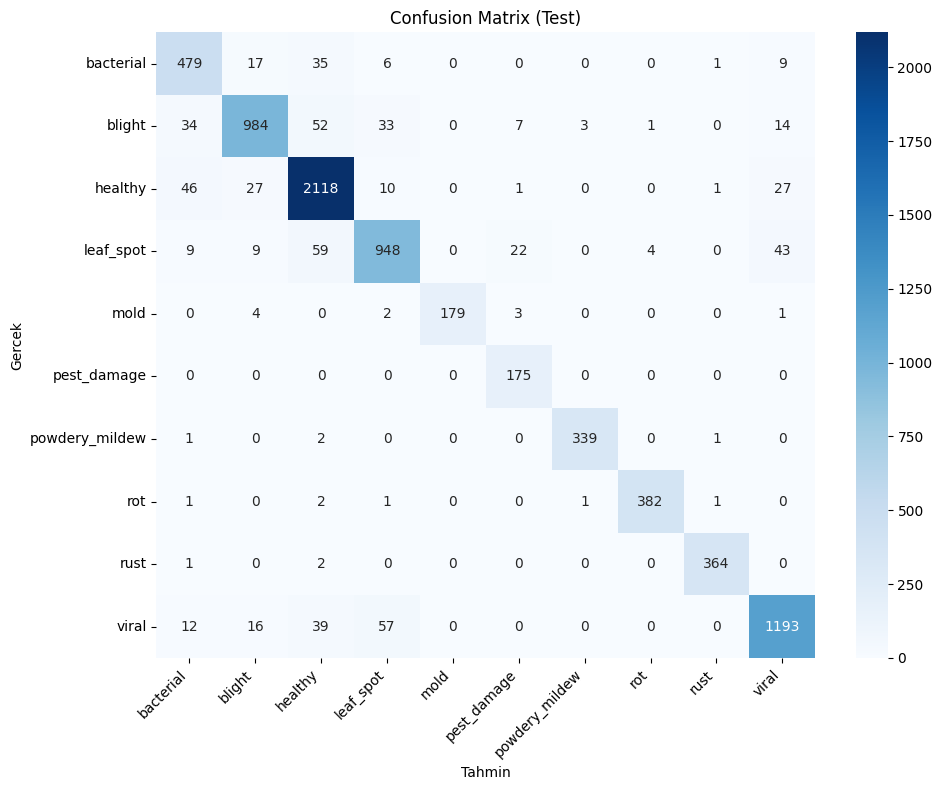

In [23]:
# Ne: Confusion matrix ve sinif bazli metrikler
# Neden: Hangi hastalik siniflarinin karistigini gormek; dusuk recall'li siniflari tespit etmek

y_true, y_pred = [], []
for images, labels in test_ds:
    preds = best_model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

print(classification_report(y_true, y_pred, target_names=class_names, digits=3))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names,
            yticklabels=class_names, cmap='Blues')
plt.title('Confusion Matrix (Test)')
plt.ylabel('Gercek'); plt.xlabel('Tahmin')
plt.xticks(rotation=45, ha='right'); plt.tight_layout(); plt.show()


In [1]:
# Ne: Test Time Augmentation (TTA) ile dogrulugu artir
# Neden: Her test goruntusunu birden fazla augment ile tahmin edip ortalamak sinir durumlari iyilestirir

TTA_STEPS = 5

def tta_predict(model, image_path, n=5):
    img = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32) / 255.0
    img_batch = tf.expand_dims(img, 0)
    preds = [model(augmentation_layer(img_batch, training=True), training=False).numpy()[0]
             for _ in range(n)]
    preds.append(model(img_batch, training=False).numpy()[0])
    return np.mean(preds, axis=0)

test_imgs, test_lbls = [], []
for cls in class_names:
    cp = os.path.join(TEST_DIR, cls)
    for f in os.listdir(cp)[:5]:
        test_imgs.append(os.path.join(cp, f))
        test_lbls.append(class_names.index(cls))

tta_preds = [np.argmax(tta_predict(best_model, p, TTA_STEPS)) for p in test_imgs]
tta_acc = np.mean(np.array(tta_preds) == np.array(test_lbls))
print(f'TTA Dogrulugu (kucuk orneklem): {tta_acc:.4f} ({tta_acc*100:.2f}%)')

NameError: name 'class_names' is not defined

In [ ]:
# Ne: Ornek tahminleri gorsel olarak goster
# Neden: Sayisal metrikler yetersiz; hangi gorsellerde yanildigini gormek saglikli degerlendirme saglar

def show_samples(model, test_dir, class_names, n=12):
    samples = []
    for cls in class_names:
        cp = os.path.join(test_dir, cls)
        files = [f for f in os.listdir(cp) if Path(f).suffix.lower() in VALID_EXT]
        if files: samples.append((random.choice([os.path.join(cp, f) for f in files]), cls))
    random.shuffle(samples); samples = samples[:n]
    cols = 4; rows = math.ceil(len(samples) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(cols*3, rows*3)); axes = axes.flatten()
    for i, (img_path, true_cls) in enumerate(samples):
        img_raw = mpimg.imread(img_path)
        img_t = tf.image.resize(tf.cast(img_raw, tf.float32)/255.0, [IMG_SIZE, IMG_SIZE])
        pred = model.predict(tf.expand_dims(img_t, 0), verbose=0)[0]
        pred_cls = class_names[np.argmax(pred)]; conf = np.max(pred)
        axes[i].imshow(img_raw)
        color = 'green' if pred_cls == true_cls else 'red'
        axes[i].set_title(f'G: {true_cls}\nT: {pred_cls} ({conf:.2f})', color=color, fontsize=8)
        axes[i].axis('off')
    for j in range(i+1, len(axes)): axes[j].axis('off')
    plt.tight_layout(); plt.show()

show_samples(best_model, TEST_DIR, class_names, n=12)


In [ ]:
# Ne: Sinif isimlerini JSON'a kaydet
# Neden: TFLite modeli sinif ismi bilmez; Flutter uygulamasi bu dosyadan okur

os.makedirs(os.path.dirname(LABEL_PATH), exist_ok=True)
with open(LABEL_PATH, 'w', encoding='utf-8') as f:
    json.dump(class_names, f, ensure_ascii=False, indent=2)
print(f'Sinif isimleri kaydedildi: {LABEL_PATH}')
print(f'Siniflar: {class_names}')


In [ ]:
# Ne: Modeli TFLite formatina donustur
# Neden: Flutter .keras modelini kullanamaz; TFLite boyut ve hiz optimizasyonu saglar

converter = tf.lite.TFLiteConverter.from_keras_model(best_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

with open(TFLITE_PATH, 'wb') as f:
    f.write(tflite_model)

size_mb = os.path.getsize(TFLITE_PATH) / (1024 * 1024)
print(f'TFLite modeli kaydedildi: {TFLITE_PATH}')
print(f'Boyut: {size_mb:.2f} MB')


In [ ]:
# Ne: TFLite modelini dogrula
# Neden: Donusum sirasinda dogruluk kaybi olabilir; Flutter'a gondermeden once kontrol et

interpreter = tf.lite.Interpreter(model_path=TFLITE_PATH)
interpreter.allocate_tensors()
input_details  = interpreter.get_input_details()
output_details = interpreter.get_output_details()
print('Input shape:',  input_details[0]['shape'])
print('Output shape:', output_details[0]['shape'])

match = 0; total_v = 0
for cls_idx, cls in enumerate(class_names):
    cp = os.path.join(TEST_DIR, cls)
    files = [f for f in os.listdir(cp) if Path(f).suffix.lower() in VALID_EXT][:2]
    for f in files:
        img = tf.image.resize(tf.cast(mpimg.imread(os.path.join(cp, f)), tf.float32)/255.0,
                              [IMG_SIZE, IMG_SIZE])
        inp = np.expand_dims(img.numpy(), 0).astype(np.float32)
        interpreter.set_tensor(input_details[0]['index'], inp)
        interpreter.invoke()
        pred = interpreter.get_tensor(output_details[0]['index'])[0]
        if np.argmax(pred) == cls_idx: match += 1
        total_v += 1

print(f'TFLite mini dogrulama: {match}/{total_v} dogru ({match/total_v*100:.1f}%)')


In [ ]:
# Ne: Egitim ozeti
# Neden: Tum sonuclari tek yerde gormek; tez raporuna kolayca eklemek icin

print('=' * 55)
print('HASTALIK MODELI EGITIM OZETI')
print('=' * 55)
print(f'Sinif sayisi  : {NUM_CLASSES}')
print(f'Siniflar      : {class_names}')
print(f'Test dogrulugu: {test_acc*100:.2f}%')
print(f'TFLite boyutu : {os.path.getsize(TFLITE_PATH)/(1024*1024):.2f} MB')
print(f'Model yolu    : {MODEL_PATH}')
print(f'TFLite yolu   : {TFLITE_PATH}')
print(f'Label yolu    : {LABEL_PATH}')
print('=' * 55)
